# 02 — Exploratory Data Analysis

This notebook explores the chemical and bioactivity characteristics of the prepared human Nav1.7 dataset generated in `01_data_preparation.ipynb`.

Only compounds classified as `GOOD` during data preparation are included in the primary exploratory analysis. These compounds have a max/min IC50 ratio below 3. Confidence levels (`HIGH`, `MEDIUM`, and `LOW`) are retained to distinguish compounds according to the number of available measurements.

### Goals

The exploratory analysis will examine:

1. The distribution of Nav1.7 inhibitory activity using IC50 and pIC50
2. The distribution of molecular properties such as molecular weight
3. The number of IC50 measurements available per compound
4. Differences among confidence levels
5. Relationships between molecular properties and Nav1.7 activity
6. The chemical and activity space represented by the prepared dataset

The purpose of this notebook is to characterize the dataset, identify important patterns and limitations, and provide context for the machine-learning analysis performed in `03_machine_learning_models.ipynb`.

## 1. Setup and Load Prepared Data

This notebook uses the `GOOD` compound dataset generated in `01_data_preparation.ipynb`.

The dataset contains compounds whose available IC50 measurements have a max/min ratio below 3. The associated confidence levels are retained to distinguish compounds according to the number of supporting measurements.

The prepared CSV file is uploaded and loaded without repeating the filtering and structure-cleaning procedures performed in the previous notebook.

In [14]:
%pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 47.7 MB/s eta 0:00:00


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from rdkit import Chem
from rdkit.Chem import Descriptors

In [3]:
from google.colab import files

# Upload the GOOD dataset generated in 01_data_preparation.ipynb
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

good_df = pd.read_csv(file_name)

print(f"Loaded: {file_name}")
print(f"Compounds: {len(good_df):,}")
print(f"Columns: {len(good_df.columns)}")

display(good_df.head())

Saving nav17_good.csv to nav17_good.csv
Loaded: nav17_good.csv
Compounds: 6,738
Columns: 11


,molecule_chembl_id,canonical_smiles,molecular_weight,ic50_nm,pIC50,min_val,max_val,measurement_count,max_min_ratio,data_quality,confidence_level
0,CHEMBL3904041,C#Cc1cccc(OC2CN(c3ncnc(Nc4cccc(C(=O)NC)c4)n3)C...,400.164774,990.0,6.004365,990.0,990.0,1,1.000000,GOOD,LOW
1,CHEMBL3662199,C/C=C/c1cc(C(=O)NS(=O)(=O)N2CCC2)c(F)cc1OCC12C...,462.198857,6.0,8.221849,6.0,6.0,1,1.000000,GOOD,LOW
2,CHEMBL190461,C=C(C)[C@@H]1CCC(C)=C[C@H]1c1c(O)cc(CCCCC)cc1O,314.224580,1820.0,5.739929,1820.0,1820.0,1,1.000000,GOOD,LOW
3,CHEMBL3955581,C=C(C)c1ccccc1N1CCOc2cc(S(=O)(=O)Nc3nccs3)ccc21,413.086783,2420.0,5.616185,2420.0,2420.0,1,1.000000,GOOD,LOW
4,CHEMBL5805169,C=C(C)c1cn2c(NS(C)(=O)=O)nnc2cc1OCC12CC3CC(CC(...,416.188212,51.1,7.291579,51.0,51.2,2,1.003922,GOOD,MEDIUM


In [4]:
# Verify that only GOOD records are present
print(good_df['data_quality'].value_counts())

assert (good_df['data_quality'] == 'GOOD').all(), \
    "Dataset contains records not classified as GOOD."

data_quality
GOOD    6738
Name: count, dtype: int64


## 2. Nav1.7 Potency Distribution

To characterize the range of inhibitory activities represented in the dataset, compounds are grouped into four potency classes based on their median IC50 values:

- **Very Potent:** IC50 ≤ 10 nM
- **Potent:** IC50 > 10 to ≤ 100 nM
- **Medium:** IC50 > 100 to ≤ 1000 nM
- **Weak:** IC50 > 1000 nM (1 µM)

These categories provide an interpretable overview of the activity range represented in the dataset before examining the continuous IC50 and pIC50 distributions.

In [5]:
# Define IC50 potency bins in nM
bins = [0, 10, 100, 1000, np.inf]

labels = [
    'Very Potent (≤10 nM)',
    'Potent (>10–100 nM)',
    'Medium (>100–1000 nM)',
    'Weak (>1000 nM)'
]

# Assign potency class based on median IC50
good_df['potency_class'] = pd.cut(
    good_df['ic50_nm'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# Count compounds in each potency class
potency_counts = (
    good_df['potency_class']
    .value_counts(sort=False)
)

print("--- Potency Classification ---")
print(potency_counts)

--- Potency Classification ---
potency_class
Very Potent (≤10 nM)      582
Potent (>10–100 nM)      1666
Medium (>100–1000 nM)    2232
Weak (>1000 nM)          2258
Name: count, dtype: int64


## 3. Distribution of Nav1.7 Inhibitory Activity

The distribution of pIC50 values is examined to characterize the range of Nav1.7 inhibitory activities represented in the prepared dataset.

pIC50 expresses inhibitory potency on a logarithmic scale, where higher values indicate greater potency. For reference:

- **pIC50 = 6** corresponds to an IC50 of 1 µM (1000 nM)
- **pIC50 = 8** corresponds to an IC50 of 10 nM

A bin width of 0.5 pIC50 units is used to visualize the activity distribution while maintaining sufficient resolution to identify broad patterns in the dataset.

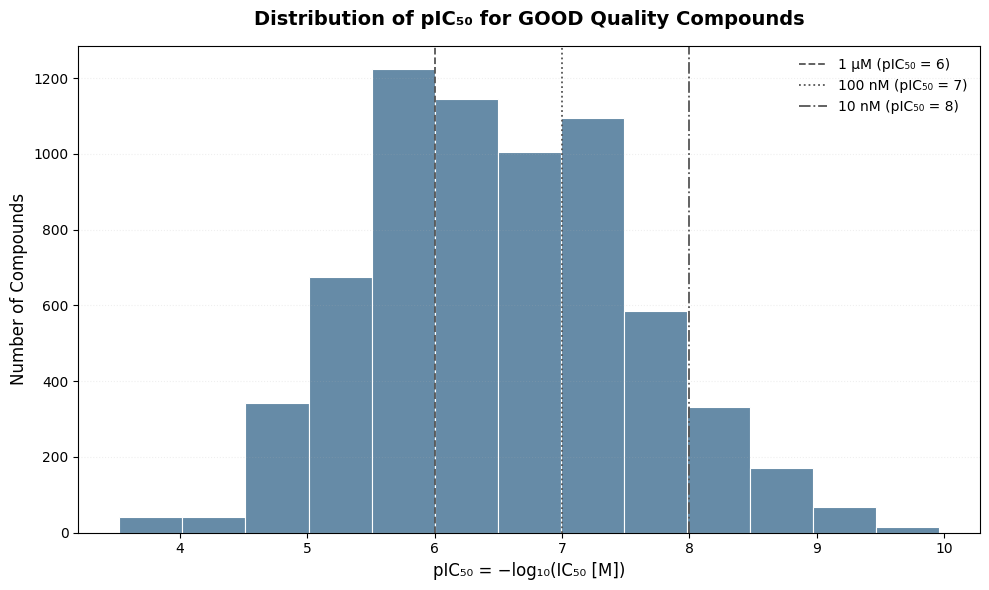

In [8]:
import seaborn as sns

# Plot pIC₅₀ distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=good_df,
    x='pIC50',
    binwidth=0.5,
    kde=False,
    color='#33658A',
    edgecolor='white',
    linewidth=0.8
)

# Potency-class reference lines
plt.axvline(
    x=6.0,
    color='#555555',
    linestyle='--',
    linewidth=1.3,
    label='1 µM (pIC₅₀ = 6)'
)

plt.axvline(
    x=7.0,
    color='#555555',
    linestyle=':',
    linewidth=1.3,
    label='100 nM (pIC₅₀ = 7)'
)

plt.axvline(
    x=8.0,
    color='#555555',
    linestyle='-.',
    linewidth=1.3,
    label='10 nM (pIC₅₀ = 8)'
)

# Formatting
plt.title(
    'Distribution of pIC₅₀ for GOOD Quality Compounds',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'pIC₅₀ = −log₁₀(IC₅₀ [M])',
    fontsize=12
)

plt.ylabel(
    'Number of Compounds',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### pIC₅₀ Distribution Summary

To complement the histogram, the pIC₅₀ values are summarized using the same 0.5-unit intervals used in the visualization. Compound counts within each interval provide the numerical distribution underlying the histogram.

Basic descriptive statistics are also reported to characterize the overall range and central tendency of Nav1.7 inhibitory activity in the prepared dataset.

In [10]:
# Determine the pIC₅₀ range and construct 0.5-unit bins
min_p = np.floor(good_df['pIC50'].min() * 2) / 2
max_p = np.ceil(good_df['pIC50'].max() * 2) / 2

bin_edges = np.arange(
    min_p,
    max_p + 0.5,
    0.5
)

# Bin pIC₅₀ values and count compounds
binned_data = pd.cut(
    good_df['pIC50'],
    bins=bin_edges,
    right=False
)

raw_counts = (
    binned_data
    .value_counts()
    .sort_index()
)

# Display histogram-bin counts
print("--- pIC₅₀ Histogram Bin Counts ---")
print(f"{'pIC₅₀ Range':<20} | {'Compound Count':<15}")
print("-" * 38)

for bin_interval, count in raw_counts.items():
    interval_str = (
        f"[{bin_interval.left:.1f}, "
        f"{bin_interval.right:.1f})"
    )
    print(f"{interval_str:<20} | {count:<15}")


# Display summary statistics
print("\n--- pIC₅₀ Summary Statistics ---")

print(f"Total Compounds: {len(good_df):,}")
print(f"Minimum pIC₅₀:   {good_df['pIC50'].min():.2f}")
print(f"Median pIC₅₀:    {good_df['pIC50'].median():.2f}")
print(f"Maximum pIC₅₀:   {good_df['pIC50'].max():.2f}")
print(f"Mean pIC₅₀:      {good_df['pIC50'].mean():.2f}")
print(f"Std. Dev.:       {good_df['pIC50'].std():.2f}")

--- pIC₅₀ Histogram Bin Counts ---
pIC₅₀ Range          | Compound Count 
--------------------------------------
[3.5, 4.0)           | 39             
[4.0, 4.5)           | 42             
[4.5, 5.0)           | 289            
[5.0, 5.5)           | 717            
[5.5, 6.0)           | 1171           
[6.0, 6.5)           | 1213           
[6.5, 7.0)           | 1019           
[7.0, 7.5)           | 1098           
[7.5, 8.0)           | 568            
[8.0, 8.5)           | 340            
[8.5, 9.0)           | 164            
[9.0, 9.5)           | 67             
[9.5, 10.0)          | 11             

--- pIC₅₀ Summary Statistics ---
Total Compounds: 6,738
Minimum pIC₅₀:   3.53
Median pIC₅₀:    6.46
Maximum pIC₅₀:   9.96
Mean pIC₅₀:      6.51
Std. Dev.:       1.03


### Initial Observation

The GOOD dataset contains 6,738 unique molecular structures spanning a broad range of Nav1.7 inhibitory activities (pIC₅₀ = 3.53–9.96).

The activity distribution is centered near pIC₅₀ 6.5, with a mean of 6.51 and median of 6.46. Most compounds fall within approximately pIC₅₀ 5–8, while relatively few compounds occur at the extreme low- and high-potency ends of the distribution.

The broad activity range provides a useful basis for subsequent investigation of relationships between molecular structure and Nav1.7 inhibitory potency.

## 4. Molecular Weight Distribution

Molecular weight is examined to characterize the molecular size range represented in the Nav1.7 dataset.

The prepared dataset was restricted to compounds with molecular weights between 100 and 1000 Da during data preparation. Here, the distribution within that range is examined using 50 Da intervals.

A reference line at 500 Da indicates the molecular-weight criterion commonly associated with Lipinski's Rule of Five. This threshold is shown as a reference for drug-like chemical space rather than as an additional filtering criterion.

Missing molecular weights: 0


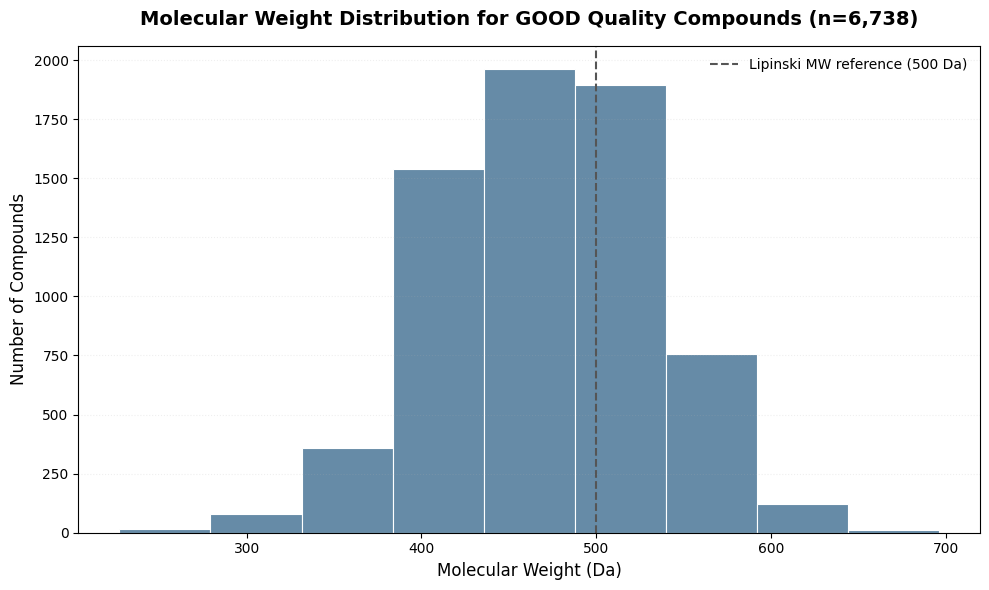

In [11]:
# Verify that molecular-weight data are complete
print(
    f"Missing molecular weights: "
    f"{good_df['molecular_weight'].isna().sum()}"
)

# Plot molecular-weight distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=good_df,
    x='molecular_weight',
    binwidth=50,
    kde=False,
    color='#33658A',
    edgecolor='white',
    linewidth=0.8
)

# Lipinski Rule-of-Five reference
plt.axvline(
    x=500,
    color='#555555',
    linestyle='--',
    linewidth=1.5,
    label='Lipinski MW reference (500 Da)'
)

plt.title(
    f'Molecular Weight Distribution for GOOD Quality Compounds '
    f'(n={len(good_df):,})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Molecular Weight (Da)',
    fontsize=12
)

plt.ylabel(
    'Number of Compounds',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### Molecular Weight Summary

Descriptive statistics are calculated to summarize the molecular-weight distribution. The proportion of compounds above 500 Da is also reported to provide context relative to the molecular-weight criterion commonly associated with Lipinski's Rule of Five.

In [12]:
# Calculate molecular-weight summary statistics
mw_mean = good_df['molecular_weight'].mean()
mw_median = good_df['molecular_weight'].median()
mw_std = good_df['molecular_weight'].std()
mw_min = good_df['molecular_weight'].min()
mw_max = good_df['molecular_weight'].max()

# Calculate compounds above the 500 Da Lipinski reference
above_500 = (good_df['molecular_weight'] > 500).sum()
above_500_pct = above_500 / len(good_df) * 100


# Display summary
print("--- Molecular Weight Summary Statistics ---")

print(f"Total Compounds:     {len(good_df):,}")
print(f"Minimum MW:          {mw_min:.2f} Da")
print(f"Mean MW:             {mw_mean:.2f} Da")
print(f"Median MW:           {mw_median:.2f} Da")
print(f"Maximum MW:          {mw_max:.2f} Da")
print(f"Std. Dev.:           {mw_std:.2f} Da")

print("\n--- Lipinski MW Reference ---")

print(f"Compounds ≤500 Da:   {len(good_df) - above_500:,}")
print(f"Compounds >500 Da:   {above_500:,}")
print(f"Percent >500 Da:     {above_500_pct:.1f}%")

--- Molecular Weight Summary Statistics ---
Total Compounds:     6,738
Minimum MW:          227.11 Da
Mean MW:             472.17 Da
Median MW:           472.07 Da
Maximum MW:          696.24 Da
Std. Dev.:           61.67 Da

--- Lipinski MW Reference ---
Compounds ≤500 Da:   4,368
Compounds >500 Da:   2,370
Percent >500 Da:     35.2%


### Initial Observation

The 6,738 compounds have a mean molecular weight of 472.17 Da and a median of 472.07 Da, indicating that the distribution is centered near 470 Da. The observed molecular-weight range (227.11–696.24 Da) is substantially narrower than the 100–1000 Da range permitted during data preparation.

Most compounds (64.8%) have molecular weights at or below the 500 Da Lipinski reference, while 35.2% exceed this threshold. The 500 Da value is used here only as a reference for molecular size and is not treated as an exclusion criterion.

## 5. Lipophilicity (LogP) Distribution

Lipophilicity is examined using the calculated octanol/water partition coefficient (LogP), a molecular property related to the balance between hydrophobic and hydrophilic character.

LogP is calculated from each compound's canonical SMILES using RDKit. The distribution is visualized using 0.5-unit intervals.

A reference line at LogP = 5 indicates the lipophilicity criterion commonly associated with Lipinski's Rule of Five. This value is shown for context and is not used as an additional filtering criterion.

In [16]:
# Calculate RDKit LogP from canonical SMILES
def calculate_logp(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return np.nan

    return Descriptors.MolLogP(mol)


good_df['logp'] = (
    good_df['canonical_smiles']
    .apply(calculate_logp)
)

# Check for failed calculations
missing_logp = good_df['logp'].isna().sum()

print(f"LogP values calculated: {good_df['logp'].notna().sum():,}")
print(f"Missing LogP values:    {missing_logp:,}")

LogP values calculated: 6,738
Missing LogP values:    0


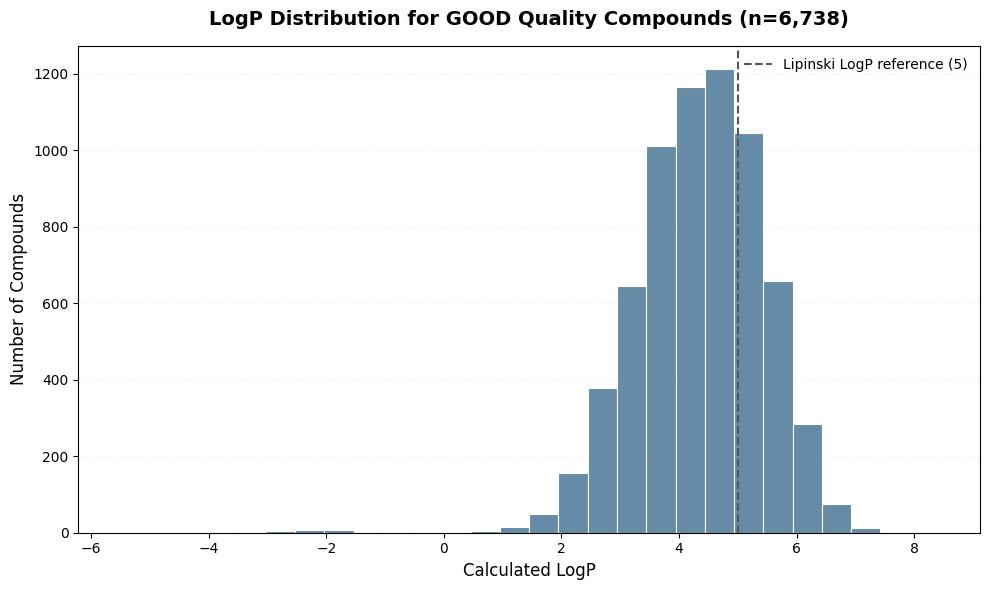

In [17]:
# Plot LogP distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=good_df,
    x='logp',
    binwidth=0.5,
    kde=False,
    color='#33658A',
    edgecolor='white',
    linewidth=0.8
)

# Lipinski Rule-of-Five reference
plt.axvline(
    x=5.0,
    color='#555555',
    linestyle='--',
    linewidth=1.5,
    label='Lipinski LogP reference (5)'
)

plt.title(
    f'LogP Distribution for GOOD Quality Compounds '
    f'(n={good_df["logp"].notna().sum():,})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Calculated LogP',
    fontsize=12
)

plt.ylabel(
    'Number of Compounds',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [18]:
# Calculate LogP summary statistics
logp_data = good_df['logp'].dropna()

above_5 = (logp_data > 5).sum()
above_5_pct = above_5 / len(logp_data) * 100

print("--- LogP Summary Statistics ---")

print(f"Total Compounds:     {len(logp_data):,}")
print(f"Minimum LogP:        {logp_data.min():.2f}")
print(f"Mean LogP:           {logp_data.mean():.2f}")
print(f"Median LogP:         {logp_data.median():.2f}")
print(f"Maximum LogP:        {logp_data.max():.2f}")
print(f"Std. Dev.:           {logp_data.std():.2f}")

print("\n--- Lipinski LogP Reference ---")

print(f"Compounds ≤5:        {len(logp_data) - above_5:,}")
print(f"Compounds >5:        {above_5:,}")
print(f"Percent >5:          {above_5_pct:.1f}%")

--- LogP Summary Statistics ---
Total Compounds:     6,738
Minimum LogP:        -5.52
Mean LogP:           4.35
Median LogP:         4.40
Maximum LogP:        8.42
Std. Dev.:           1.10

--- Lipinski LogP Reference ---
Compounds ≤5:        4,797
Compounds >5:        1,941
Percent >5:          28.8%


### Initial Observation

The 6,738 compounds have a mean calculated LogP of 4.35 and a median of 4.40, indicating that the dataset is centered toward relatively lipophilic chemical space.

Most compounds (71.2%) have calculated LogP values at or below the Lipinski reference of 5, while 28.8% exceed this value. The distribution is concentrated primarily around LogP values of approximately 3–6, although a small number of compounds extend into substantially more hydrophilic or lipophilic regions.

As with molecular weight, the Lipinski threshold is used only as a reference for describing the chemical space and is not treated as an exclusion criterion.

## 6. Measurement Count and Experimental Support

The number of IC₅₀ measurements available for each compound is examined to characterize the amount of experimental evidence supporting the representative median IC₅₀ value.

Compounds with repeated measurements provide greater opportunity to assess measurement agreement, while compounds represented by a single measurement have more limited experimental support.

These measurement counts form the basis of the confidence classifications defined during data preparation:

- **HIGH:** 3 or more measurements
- **MEDIUM:** 2 measurements
- **LOW:** 1 measurement

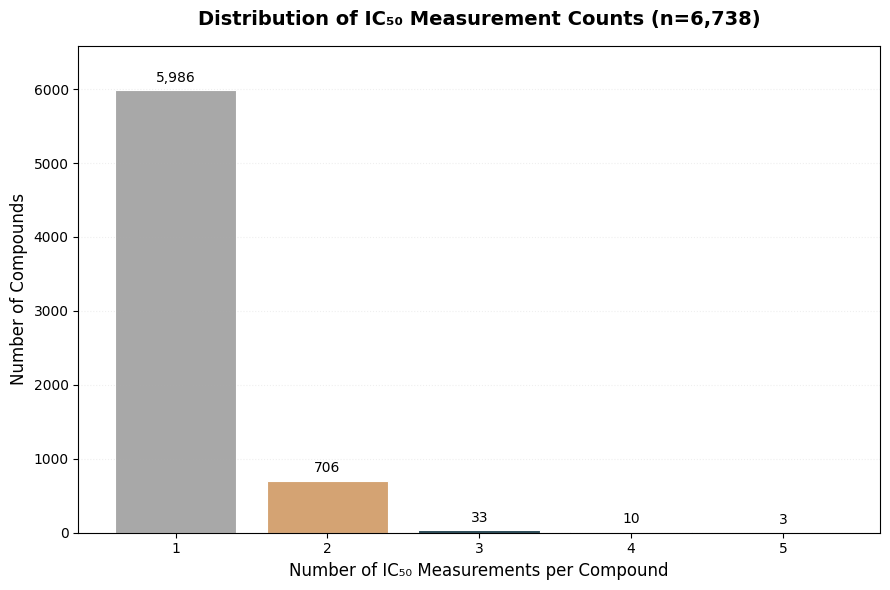

In [19]:
# Count compounds by number of IC₅₀ measurements
mc_counts = (
    good_df['measurement_count']
    .value_counts()
    .sort_index()
)

# Assign colors according to confidence level
bar_colors = [
    '#A8A8A8' if n == 1 else       # LOW
    '#D4A373' if n == 2 else       # MEDIUM
    '#264653'                       # HIGH
    for n in mc_counts.index
]

# Create bar plot
plt.figure(figsize=(9, 6))

ax = plt.bar(
    mc_counts.index,
    mc_counts.values,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

# Add compound counts above each bar
for bar in ax:
    height = bar.get_height()

    plt.annotate(
        f'{int(height):,}',
        xy=(
            bar.get_x() + bar.get_width() / 2,
            height
        ),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Formatting
plt.title(
    f'Distribution of IC₅₀ Measurement Counts '
    f'(n={len(good_df):,})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Number of IC₅₀ Measurements per Compound',
    fontsize=12
)

plt.ylabel(
    'Number of Compounds',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.ylim(
    0,
    mc_counts.max() * 1.10
)

plt.tight_layout()
plt.show()

In [20]:
# Summarize compounds by confidence level
confidence_counts = (
    good_df['confidence_level']
    .value_counts()
    .reindex(['LOW', 'MEDIUM', 'HIGH'])
)

confidence_pct = (
    confidence_counts / len(good_df) * 100
)

print("--- Experimental Confidence Summary ---")

for level in ['LOW', 'MEDIUM', 'HIGH']:
    print(
        f"{level:<6}: "
        f"{confidence_counts[level]:>5,} compounds "
        f"({confidence_pct[level]:.1f}%)"
    )

--- Experimental Confidence Summary ---
LOW   : 5,986 compounds (88.8%)
MEDIUM:   706 compounds (10.5%)
HIGH  :    46 compounds (0.7%)


### Initial Observation

Most compounds in the GOOD dataset are supported by a single IC₅₀ measurement. Of the 6,738 compounds, 5,986 (88.8%) are classified as LOW confidence, while 706 (10.5%) are supported by two measurements and classified as MEDIUM confidence. Only 46 compounds (0.7%) have three or more measurements and are classified as HIGH confidence.

Therefore, although all compounds in the dataset satisfy the GOOD data-quality criterion, the amount of experimental support varies substantially. In particular, the GOOD classification of single-measurement compounds reflects the absence of observed disagreement rather than demonstrated reproducibility.

This limitation should be considered when interpreting subsequent exploratory analyses and machine-learning results.

## 7. Relationship Between Lipophilicity and Nav1.7 Potency

To investigate whether lipophilicity is associated with Nav1.7 inhibitory activity, calculated LogP is compared with pIC₅₀.

Two correlation measures are reported:

- **Pearson correlation (r):** measures the strength of a linear relationship between LogP and pIC₅₀.
- **Spearman correlation (ρ):** measures the strength of a monotonic relationship and is less sensitive to non-normal distributions and extreme values.

A linear regression line is included to visualize the overall trend. Because the dataset contains a large number of compounds, correlation magnitude and the visible pattern are considered alongside statistical significance.

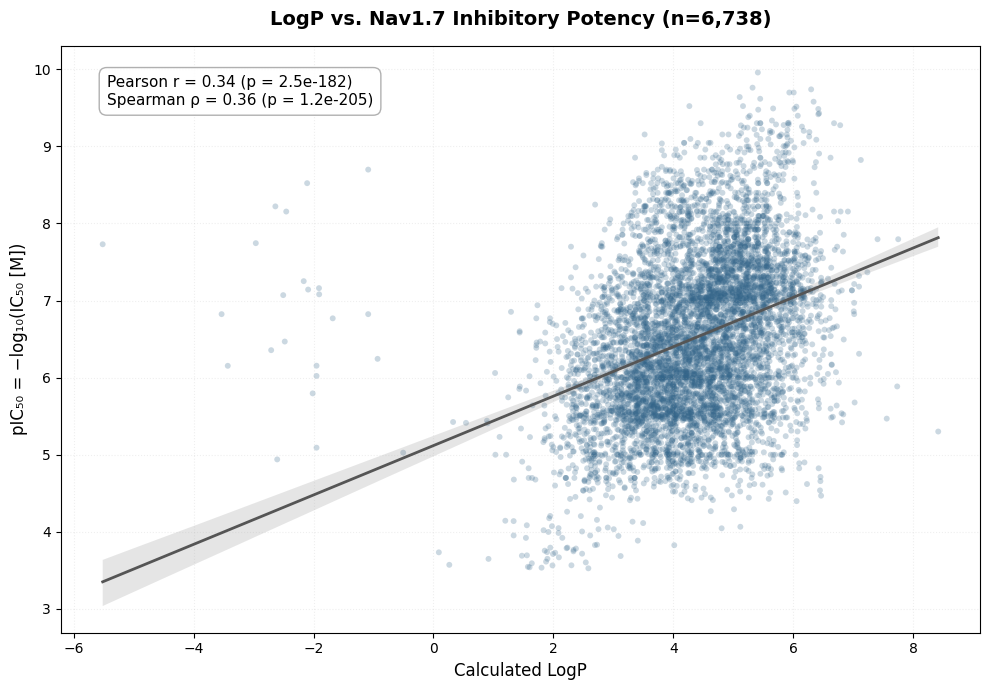

--- LogP vs. pIC₅₀ Correlation ---
Pearson r:    0.340
Pearson p:    2.475e-182
Spearman ρ:   0.360
Spearman p:   1.198e-205


In [22]:
# Remove rows with missing LogP or pIC₅₀ values
property_df = good_df.dropna(
    subset=['logp', 'pIC50']
).copy()


# Calculate Pearson and Spearman correlations
pearson_r, p_pearson = stats.pearsonr(
    property_df['logp'],
    property_df['pIC50']
)

spearman_rho, p_spearman = stats.spearmanr(
    property_df['logp'],
    property_df['pIC50']
)


# Create scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=property_df,
    x='logp',
    y='pIC50',
    color='#33658A',
    alpha=0.25,
    edgecolor='none',
    s=18
)

# Add linear trend line
sns.regplot(
    data=property_df,
    x='logp',
    y='pIC50',
    scatter=False,
    color='#555555',
    line_kws={
        'linewidth': 2,
        'linestyle': '-'
    }
)


# Add correlation statistics
stats_text = (
    f"Pearson r = {pearson_r:.2f} (p = {p_pearson:.1e})\n"
    f"Spearman ρ = {spearman_rho:.2f} (p = {p_spearman:.1e})"
)

plt.gca().text(
    0.05,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.9,
        edgecolor='#A8A8A8'
    )
)


# Formatting
plt.title(
    f'LogP vs. Nav1.7 Inhibitory Potency (n={len(property_df):,})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Calculated LogP',
    fontsize=12
)

plt.ylabel(
    'pIC₅₀ = −log₁₀(IC₅₀ [M])',
    fontsize=12
)

plt.grid(
    True,
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()


# Print numerical results
print("--- LogP vs. pIC₅₀ Correlation ---")
print(f"Pearson r:    {pearson_r:.3f}")
print(f"Pearson p:    {p_pearson:.3e}")
print(f"Spearman ρ:   {spearman_rho:.3f}")
print(f"Spearman p:   {p_spearman:.3e}")

### Initial Observation

Calculated LogP shows a moderate positive association with Nav1.7 inhibitory potency. Pearson correlation gives **r = 0.34**, while Spearman correlation gives **ρ = 0.36**. Both correlations are statistically significant (p < 10⁻¹⁸⁰).

The similar Pearson and Spearman coefficients indicate that the observed positive association is not limited to a strictly linear relationship and is broadly preserved when compounds are ranked by LogP and potency.

Overall, compounds with higher calculated lipophilicity tend to exhibit higher pIC₅₀ values, corresponding to greater Nav1.7 inhibitory potency. However, the substantial spread in pIC₅₀ at similar LogP values shows that lipophilicity alone does not determine activity.

Because of the large dataset size (n = 6,738), the very small p-values should not be interpreted as evidence of a strong relationship. The correlation coefficients indicate that the magnitude of the association is moderate.

## 8. Lipophilicity Across Potency Classes

To further examine the relationship between lipophilicity and Nav1.7 inhibitory activity, calculated LogP values are compared across the four potency classes defined earlier:

- **Weak:** IC₅₀ > 1000 nM
- **Medium:** IC₅₀ > 100 to ≤ 1000 nM
- **Potent:** IC₅₀ > 10 to ≤ 100 nM
- **Very Potent:** IC₅₀ ≤ 10 nM

Box plots show the distribution of calculated LogP within each potency class. The center line represents the median, while the mean is shown separately as a white circular marker.

This comparison complements the continuous correlation analysis by showing how the distribution of lipophilicity changes across interpretable activity categories.

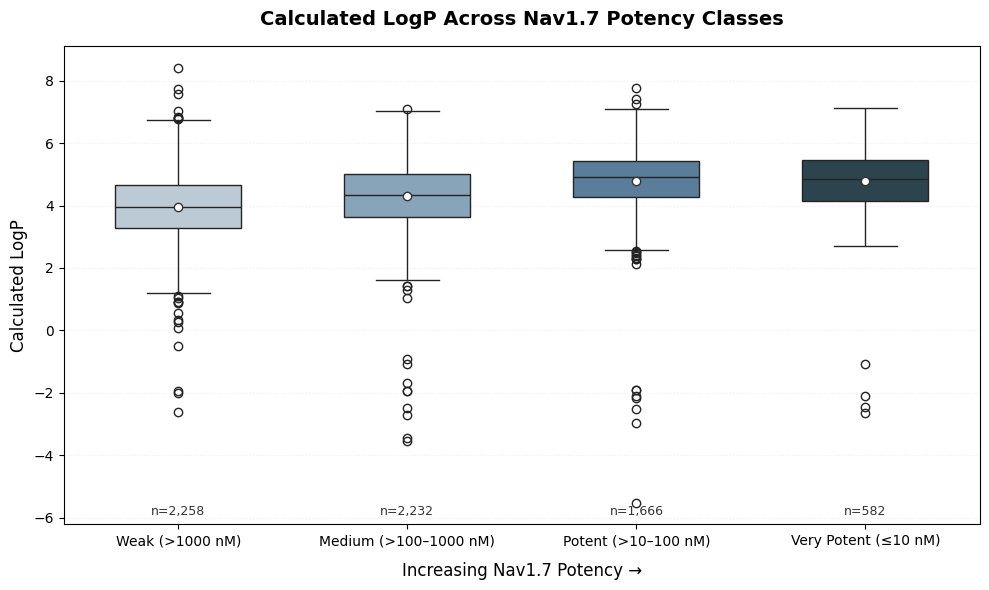

In [23]:
# Remove records missing LogP or potency classification
potency_logp_df = good_df.dropna(
    subset=['logp', 'potency_class']
).copy()

# Maintain the potency order defined previously
potency_order = [
    'Weak (>1000 nM)',
    'Medium (>100–1000 nM)',
    'Potent (>10–100 nM)',
    'Very Potent (≤10 nM)'
]

# Sequential blue palette: increasing potency
potency_colors = [
    '#B8CBD9',
    '#7FA6C0',
    '#4F7FA3',
    '#264653'
]

# Create box plot
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=potency_logp_df,
    x='potency_class',
    y='logp',
    order=potency_order,
    hue='potency_class',
    palette=dict(zip(potency_order, potency_colors)),
    legend=False,
    width=0.55,
    showmeans=True,
    meanprops={
        'marker': 'o',
        'markerfacecolor': 'white',
        'markeredgecolor': '#333333',
        'markersize': 6
    }
)

# Add sample size beneath each category
group_counts = (
    potency_logp_df['potency_class']
    .value_counts()
)

y_min, y_max = ax.get_ylim()

for i, category in enumerate(potency_order):
    count = group_counts.get(category, 0)

    ax.text(
        i,
        y_min + 0.2,
        f'n={count:,}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#333333'
    )

# Formatting
plt.title(
    'Calculated LogP Across Nav1.7 Potency Classes',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Increasing Nav1.7 Potency →',
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    'Calculated LogP',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()

In [24]:
# Calculate LogP summary statistics by potency class
summary_stats = (
    potency_logp_df
    .groupby('potency_class', observed=False)['logp']
    .describe(percentiles=[0.25, 0.50, 0.75])
)

print("--- LogP Summary by Potency Class ---")

for category in potency_order:
    row = summary_stats.loc[category]

    median_val = row['50%']
    q25 = row['25%']
    q75 = row['75%']

    print(
        f"{category}: "
        f"median {median_val:.2f}, "
        f"IQR {q25:.2f}–{q75:.2f}"
    )

--- LogP Summary by Potency Class ---
Weak (>1000 nM): median 3.95, IQR 3.27–4.65
Medium (>100–1000 nM): median 4.34, IQR 3.63–5.02
Potent (>10–100 nM): median 4.90, IQR 4.27–5.42
Very Potent (≤10 nM): median 4.85, IQR 4.16–5.45


### Initial Observation

Calculated LogP generally increases with Nav1.7 inhibitory potency from the Weak through Potent classes. Median LogP increases from 3.95 for Weak compounds to 4.34 for Medium compounds and 4.90 for Potent compounds.

However, this trend does not continue in the Very Potent class, which has a slightly lower median LogP of 4.85. The Potent and Very Potent groups also have strongly overlapping interquartile ranges (4.27–5.42 and 4.16–5.45, respectively).

These results suggest that the positive relationship between lipophilicity and potency may not continue indefinitely. Instead, the association appears to plateau around the LogP range represented by the Potent and Very Potent compounds. This pattern is consistent with the possibility that lipophilicity has a favorable range rather than a simple “higher is better” relationship.

Further analysis is required before interpreting this pattern as evidence of an optimal LogP, since potency depends on multiple molecular and structural properties and the present analysis is observational.

## 9. Relationship Between Molecular Weight and Nav1.7 Potency

To examine whether molecular size is associated with Nav1.7 inhibitory activity, molecular weight is compared with pIC₅₀.

As in the LogP analysis, both Pearson and Spearman correlations are calculated:

- **Pearson correlation (r):** measures the strength of the linear relationship between molecular weight and pIC₅₀.
- **Spearman correlation (ρ):** measures the strength of the monotonic relationship based on ranked values.

A linear regression line is included to visualize the overall trend. Correlation magnitude and the distribution of individual compounds are considered alongside statistical significance.

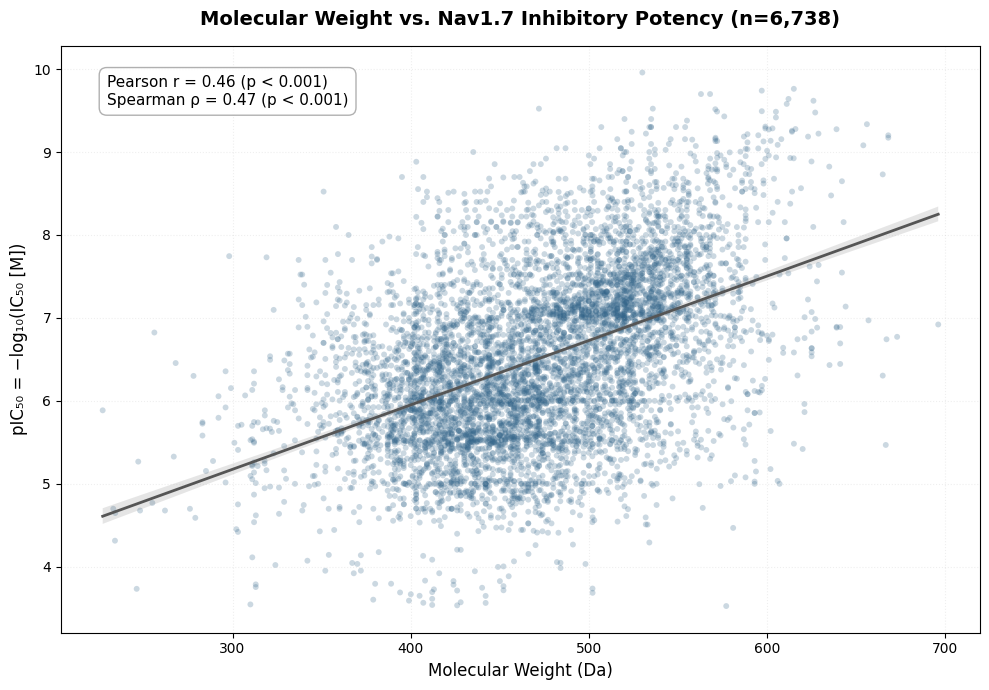

--- Molecular Weight vs. pIC₅₀ Correlation ---
Pearson r:    0.464
Pearson p:    0.000e+00
Spearman ρ:   0.468
Spearman p:   0.000e+00


In [26]:
# Remove rows with missing molecular weight or pIC₅₀
mw_activity_df = good_df.dropna(
    subset=['molecular_weight', 'pIC50']
).copy()


# Calculate Pearson and Spearman correlations
pearson_r, p_pearson = stats.pearsonr(
    mw_activity_df['molecular_weight'],
    mw_activity_df['pIC50']
)

spearman_rho, p_spearman = stats.spearmanr(
    mw_activity_df['molecular_weight'],
    mw_activity_df['pIC50']
)


# Create scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=mw_activity_df,
    x='molecular_weight',
    y='pIC50',
    color='#33658A',
    alpha=0.25,
    edgecolor='none',
    s=18
)

# Add linear trend line
sns.regplot(
    data=mw_activity_df,
    x='molecular_weight',
    y='pIC50',
    scatter=False,
    color='#555555',
    line_kws={
        'linewidth': 2,
        'linestyle': '-'
    }
)


# Add correlation statistics
def format_p(p):
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"

stats_text = (
    f"Pearson r = {pearson_r:.2f} ({format_p(p_pearson)})\n"
    f"Spearman ρ = {spearman_rho:.2f} ({format_p(p_spearman)})"
)

plt.gca().text(
    0.05,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.9,
        edgecolor='#A8A8A8'
    )
)


# Formatting
plt.title(
    f'Molecular Weight vs. Nav1.7 Inhibitory Potency '
    f'(n={len(mw_activity_df):,})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Molecular Weight (Da)',
    fontsize=12
)

plt.ylabel(
    'pIC₅₀ = −log₁₀(IC₅₀ [M])',
    fontsize=12
)

plt.grid(
    True,
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()


# Print numerical results
print("--- Molecular Weight vs. pIC₅₀ Correlation ---")
print(f"Pearson r:    {pearson_r:.3f}")
print(f"Pearson p:    {p_pearson:.3e}")
print(f"Spearman ρ:   {spearman_rho:.3f}")
print(f"Spearman p:   {p_spearman:.3e}")

### Initial Observation

Molecular weight shows a moderate positive association with Nav1.7 inhibitory potency. Pearson correlation gives **r = 0.464**, while Spearman correlation gives **ρ = 0.468**.

The close agreement between the Pearson and Spearman coefficients indicates that the positive association is also preserved when compounds are considered by rank. Overall, compounds with higher molecular weights tend to have higher pIC₅₀ values within this dataset.

The association with molecular weight is stronger than the corresponding association observed for calculated LogP (Pearson r = 0.340; Spearman ρ = 0.360). However, substantial variation in pIC₅₀ remains among compounds of similar molecular weight, indicating that molecular size alone does not determine Nav1.7 inhibitory potency.

As with the LogP analysis, this relationship is observational and should not be interpreted as evidence that increasing molecular weight directly causes greater potency.

## 10. Molecular Weight Across Potency Classes

To further examine the relationship between molecular size and Nav1.7 inhibitory activity, molecular-weight distributions are compared across the four potency classes defined earlier:

- **Weak:** IC₅₀ > 1000 nM
- **Medium:** IC₅₀ > 100 to ≤ 1000 nM
- **Potent:** IC₅₀ > 10 to ≤ 100 nM
- **Very Potent:** IC₅₀ ≤ 10 nM

Box plots show the distribution of molecular weight within each potency class. The center line represents the median, while the white circular marker represents the mean.

This categorical comparison complements the continuous correlation analysis and helps determine whether the positive association between molecular weight and pIC₅₀ persists across increasing levels of Nav1.7 potency.

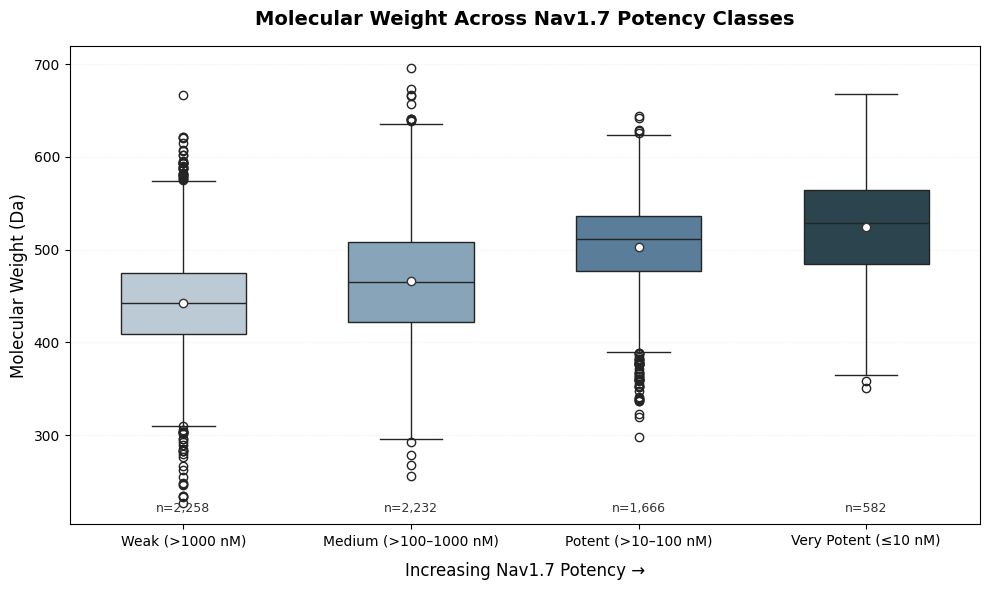

In [27]:
# Remove records missing molecular weight or potency classification
potency_mw_df = good_df.dropna(
    subset=['molecular_weight', 'potency_class']
).copy()

# Maintain the potency order defined previously
potency_order = [
    'Weak (>1000 nM)',
    'Medium (>100–1000 nM)',
    'Potent (>10–100 nM)',
    'Very Potent (≤10 nM)'
]

# Sequential blue palette: increasing potency
potency_colors = [
    '#B8CBD9',
    '#7FA6C0',
    '#4F7FA3',
    '#264653'
]

# Create box plot
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=potency_mw_df,
    x='potency_class',
    y='molecular_weight',
    order=potency_order,
    hue='potency_class',
    palette=dict(zip(potency_order, potency_colors)),
    legend=False,
    width=0.55,
    showmeans=True,
    meanprops={
        'marker': 'o',
        'markerfacecolor': 'white',
        'markeredgecolor': '#333333',
        'markersize': 6
    }
)

# Add sample size for each potency class
group_counts = (
    potency_mw_df['potency_class']
    .value_counts()
)

y_min, y_max = ax.get_ylim()

for i, category in enumerate(potency_order):
    count = group_counts.get(category, 0)

    ax.text(
        i,
        y_min + 10,
        f'n={count:,}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#333333'
    )

# Formatting
plt.title(
    'Molecular Weight Across Nav1.7 Potency Classes',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Increasing Nav1.7 Potency →',
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    'Molecular Weight (Da)',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()

In [28]:
# Calculate molecular-weight summary statistics by potency class
mw_summary_stats = (
    potency_mw_df
    .groupby('potency_class', observed=False)['molecular_weight']
    .describe(percentiles=[0.25, 0.50, 0.75])
)

print("--- Molecular Weight Summary by Potency Class ---")

for category in potency_order:
    row = mw_summary_stats.loc[category]

    median_val = row['50%']
    q25 = row['25%']
    q75 = row['75%']

    print(
        f"{category}: "
        f"median {median_val:.2f} Da, "
        f"IQR {q25:.2f}–{q75:.2f} Da"
    )

--- Molecular Weight Summary by Potency Class ---
Weak (>1000 nM): median 442.05 Da, IQR 409.09–475.10 Da
Medium (>100–1000 nM): median 465.18 Da, IQR 422.21–508.08 Da
Potent (>10–100 nM): median 511.13 Da, IQR 477.23–536.11 Da
Very Potent (≤10 nM): median 528.54 Da, IQR 484.03–563.81 Da


### Initial Observation

Molecular weight increases consistently across the four Nav1.7 potency classes. Median molecular weight rises from 442.05 Da for Weak compounds to 465.18 Da for Medium compounds, 511.13 Da for Potent compounds, and 528.54 Da for Very Potent compounds.

This progression is consistent with the moderate positive association observed between molecular weight and pIC₅₀ (Pearson r = 0.464; Spearman ρ = 0.468). In contrast to the LogP analysis, where median lipophilicity plateaued between the Potent and Very Potent classes, median molecular weight continues to increase in the Very Potent group.

The distributions nevertheless overlap substantially, indicating that molecular weight alone does not distinguish potency classes. The observed relationship is associative rather than causal and may reflect other structural features correlated with molecular size.